In [ ]:
import DataMakar
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time
import optuna

import pandas

/opt/homebrew/Cellar/micromamba/2.3.1/envs/ml-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# some exp params

ssplist = ["126","245","370","585"]

latsel = 40
lonsel = 250
experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 3

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [4]:
seed = 42

np.random.seed(seed)

trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)
trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

baseline for gmt is 60 90
experiment era in the historical is 50 117
baseline for temp records is 0 50
indices of future period are 104 -2
working on 126
working on 245
working on 370
working on 585


In [5]:
batch_size = 128
lr = 0.01
ridge_pen = 1e-6
lr_patience = 7
early_stopping_patience = 20
epochs = 2000

In [ ]:
def train_loop(dataloader, cnn, loss_fn, optimizer,device):
    
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    cnn.train()
    for batch, (x1,x2,y) in enumerate(dataloader):

        x1, x2, y = x1.to(device), x2.to(device), y.to(device)

        # Compute prediction and loss
        pred = cnn(x1,x2)
        # pred = model(X1)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(x1)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def val_loop(dataloader, model, loss_fn, optimizer, scheduler, device):
        # Set the model to evaluation mode - important for batch normalization and dropout layers
        # Unnecessary in this situation but added for best practices
        model.eval()
        size = len(dataloader.dataset)
        num_batches = len(dataloader)

        all_pred = []
        all_true = []
        all_losses = []

        with torch.no_grad():

            for x1,x2, y in dataloader:
                # Move the data and targets to the specified device
                x1, x2, y = x1.to(device), x2.to(device), y.to(device)
                
                # Forward pass
                pred = model(x1,x2)

                all_pred.extend(pred.detach().cpu().numpy())
                all_true.extend(y.detach().cpu().numpy())

                # Calculate individual losses
                batch_losses = loss_fn(pred, y)  # This returns a tensor of losses for each item in the batch
                all_losses.append(batch_losses.item())  # Convert tensor to scalar and store
        # Compute the overall loss (sum of individual losses divided by the number of samples)
        valid_loss = batch_losses.mean()

        all_pred = np.asarray(all_pred)[:,1]
        all_true = np.asarray(all_true)[:,1]

        print(f"validation loss: {valid_loss:>7f}")
        
        scheduler.step(valid_loss)
        after_lr = optimizer.param_groups[0]["lr"]
        print(f"learning rate: {after_lr:>7f}")

        return valid_loss

def model_checkpoint(model,val_loss,best_val_loss,epochs_no_improve,fileout,patience):

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print("Loss improved, saving model to "+ fileout)
        torch.save(model.state_dict(), fileout)
        epochs_no_improve = 0
        earlystopping=0
    else:
        epochs_no_improve += 1
        print("Loss did not improve")
        if epochs_no_improve == patience:
            earlystopping=1
        else:
            earlystopping=0
    
    return best_val_loss, earlystopping, epochs_no_improve

def model_checkpoint_nosave(val_loss,best_val_loss,epochs_no_improve,patience):

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        earlystopping=0
    else:
        epochs_no_improve += 1
        print("Loss did not improve")
        if epochs_no_improve == patience:
            earlystopping=1
        else:
            earlystopping=0
    
    return best_val_loss, earlystopping, epochs_no_improve

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available() & torch.backends.mps.is_built():
    device = 'mps'
else:
    device='cpu'

print(f"Using device: {device}")

# batch_size = 64
# lr = 0.01
# ridge_pen = 1e-6
# lr_patience = 10
# early_stopping_patience = 20
# epochs = 300

inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)

traindataset = TensorDataset(inputtrain,inputtrainGMT,outputtrain)
train_loader = DataLoader(traindataset,batch_size=batch_size,shuffle=True)

valdataset = TensorDataset(inputval,inputvalGMT,outputval)
val_loader = DataLoader(valdataset,batch_size=inputval.size(0),shuffle=False)

# lightly weight the class imbalance

classimbalance = outputtrain.mean(axis=0)

weights = max(classimbalance)/classimbalance

if classimbalance[0]<0.47:

    # weights = max(classimbalance)/classimbalance
    weights_corrected = [weights[0]-0.5*weights[0],weights[1]]
    weights_corrected = torch.tensor(weights_corrected).to(device)

elif classimbalance[0]>0.53:

    # weights = max(classimbalance)/classimbalance
    weights_corrected = [weights[0],weights[1]-0.5*weights[1]]
    weights_corrected = torch.tensor(weights_corrected).to(device)

else:
    weights_corrected = torch.tensor([1,1]).to(device)

print(weights_corrected)

loss_fn = nn.CrossEntropyLoss(weight=weights_corrected)

Using device: mps


In [ ]:
class CNN(nn.Module):
    def __init__(self,trial,in_data1, in_data2, out_data):
        super(CNN, self).__init__()
        
        out_size = out_data.size(-1)
        self.inputshape1 = in_data1.size()
        self.inputshape2 = in_data2.size()

        # Tune the number of convolutional blocks
        self.num_conv_blocks = trial.suggest_int('num_conv_blocks', 1, 4)
        filterlist = []
        
        self.conv_layers = nn.ModuleList()
        
        num_filters = trial.suggest_int('num_filters', 4, 64, step=4, log=True)

        filterlist.append(num_filters)
        self.conv_layers.append(nn.Conv2d(in_channels=self.inputshape1[1], out_channels=num_filters, kernel_size=3, padding=1))
        self.conv_layers.append(nn.ReLU())
        self.conv_layers.append(nn.AvgPool2d(kernel_size=2, stride=2))
        trial.set_user_attr(f'num_filters', num_filters)

        for i in range(self.num_conv_blocks-1):
            # Tune the number of filters in each convolutional layer
            num_filters = trial.suggest_int(f'num_filters', 4, 16, step=4)
            self.conv_layers.append(nn.Conv2d(in_channels=filterlist[i], out_channels=num_filters, kernel_size=3, padding=1))
            self.conv_layers.append(nn.ReLU())
            self.conv_layers.append(nn.AvgPool2d(kernel_size=2, stride=2))
            filterlist.append(num_filters)
            trial.set_user_attr(f'num_filter_layer_{i+1}', num_filters)
        
        self.flatten = nn.Flatten()
        
        # Tune the number of hidden layers and the number of nodes in each layer
        self.num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 4)
        self.linear_layers = nn.ModuleList()

        num_nodes = trial.suggest_int(f'num_nodes_layer_0', 10, 200, step=10,log=True)
        self.linear_layers.append(nn.Linear(in_features=self.get_flatten_size()+1, out_features=num_nodes))
        self.linear_layers.append(nn.ReLU())

        trial.set_user_attr(f'num_nodes_layer_0', num_nodes)

        nodelist = []
        nodelist.append(num_nodes)
        
        for i in range(self.num_hidden_layers-1):   
            num_nodes = trial.suggest_int(f'num_nodes_layer_{i+1}', 10, 200, step=10,log=True)
            self.linear_layers.append(nn.Linear(in_features=nodelist[i], out_features=num_nodes))         
            self.linear_layers.append(nn.ReLU())
            nodelist.append(num_nodes)
            trial.set_user_attr(f'num_nodes_layer_{i+1}', num_nodes)
        
        self.output_layer = nn.Linear(in_features=nodelist[-1], out_features=out_size)
        self.softmax = nn.Softmax(dim=1)
        
    def get_flatten_size(self):
        sample = torch.randn(1, self.inputshape1[1], self.inputshape1[2], self.inputshape1[3])
        with torch.no_grad():
            x = sample
            for layer in self.conv_layers:
                x = layer(x)
        return x.view(x.size(0), -1).size(1)
        
    def forward(self, x1,x2):
        for layer in self.conv_layers:
            x1 = layer(x1)
        x = self.flatten(x1)
        x = torch.cat((x, x2), dim=1)
        for layer in self.linear_layers:
            x = layer(x)
        x = self.output_layer(x)
        x = self.softmax(x)
        return x

def objective(trial):
    model = CNN(trial,inputtrain,inputtrainGMT,outputtrain).to(device)
    print(model)
    optimizer = optim.SGD(model.parameters(), 
                lr=lr,
                weight_decay=ridge_pen
                )
    
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, threshold=1e-4, factor=0.1, patience=lr_patience, cooldown=0, min_lr=5e-6)
    loss_fn = nn.CrossEntropyLoss(weight=weights_corrected)

    loss = []

    best_val_loss = np.inf
    epochs_no_improve = 0

    print('train loop')
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        time1 = time.time()

        train_loop(train_loader, model, loss_fn, optimizer, device)
        valid_loss = val_loop(val_loader, model, loss_fn, optimizer, scheduler, device)

        loss.append(valid_loss)
        time2 = time.time()
        print(f"{time2-time1:4f} seconds per epoch")
        best_val_loss, earlystopping, epochs_no_improve = model_checkpoint_nosave(valid_loss,best_val_loss,epochs_no_improve,early_stopping_patience)
        if earlystopping==1:

            print(f'Early stopping after {t+1} epochs.')
            break
        
    return best_val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_trial = study.best_trial
print('Best trial:')
print(f'  Value: {best_trial.value}')
print('  Params:')
for key, value in best_trial.params.items():
    print(f'    {key}: {value}')

[I 2025-08-28 13:35:43,866] A new study created in memory with name: no-name-1a75a98a-72a2-4b1d-b7e8-84f44c619978


CNN(
  (conv_layers): ModuleList(
    (0): Conv2d(10, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layers): ModuleList(
    (0): Linear(in_features=11881, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=80, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=80, out_features=2, bias=True)
  (softmax): Softmax(dim=1)
)
train loop
Epoch 1
-------------------------------
loss: 0.785055  [   64/ 4225]
validation loss: 0.770220
validation brier score: 0.246879
learning rate: 0.010000
8.242425 seconds per epoch
Epoch 2
-------------------------------
loss: 0.784317  [   64/ 4225]
validation loss: 0.767834
validation brier score: 0.245557
learning rate: 0.010000
0.537391 seconds per epoch
Epoch 3
-------------------------------
loss: 0.758034  [   64/ 4225]
validation l

[I 2025-08-28 13:36:14,430] Trial 0 finished with value: 0.4963427782058716 and parameters: {'num_conv_blocks': 1, 'num_filters': 12, 'num_hidden_layers': 2, 'num_nodes_layer_0': 80, 'num_nodes_layer_1': 80}. Best is trial 0 with value: 0.4963427782058716.


validation loss: 0.498386
validation brier score: 0.112792
learning rate: 0.001000
0.503418 seconds per epoch
Loss did not improve
Early stopping after 49 epochs.
CNN(
  (conv_layers): ModuleList(
    (0): Conv2d(10, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layers): ModuleList(
    (0): Linear(in_features=2905, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=20, bias=True)
    (3): ReLU()
  )
  (output_layer): Linear(in_features=20, out_features=2, bias=True)
  (softmax): Softmax(dim=1)
)
train loop
Epoch 1
-------------------------------
loss: 0.751018  [   64/ 4225]
validation loss: 0.770488
validatio

[I 2025-08-28 13:36:52,714] Trial 1 finished with value: 0.4792187213897705 and parameters: {'num_conv_blocks': 2, 'num_filters': 12, 'num_hidden_layers': 2, 'num_nodes_layer_0': 40, 'num_nodes_layer_1': 20}. Best is trial 1 with value: 0.4792187213897705.


...

validation loss: 0.471023
validation brier score: 0.096731
learning rate: 0.001000
0.398365 seconds per epoch
Loss did not improve
Early stopping after 120 epochs.
CNN(
  (conv_layers): ModuleList(
    (0): Conv2d(10, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layers): ModuleList(
    (0): Linear(in_features=221, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=60, bias=True)
    (3): ReLU()
    (4): Linear(in_features=60, out_features=80,

[I 2025-08-28 14:24:11,116] Trial 48 finished with value: 0.46979379653930664 and parameters: {'num_conv_blocks': 3, 'num_filters': 4, 'num_hidden_layers': 3, 'num_nodes_layer_0': 40, 'num_nodes_layer_1': 60, 'num_nodes_layer_2': 80}. Best is trial 47 with value: 0.4696458876132965.


validation loss: 0.469902
validation brier score: 0.095410
learning rate: 0.000100
0.389600 seconds per epoch
Loss did not improve
Early stopping after 138 epochs.
CNN(
  (conv_layers): ModuleList(
    (0): Conv2d(10, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layers): ModuleList(
    (0): Linear(in_features=221, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=80,

[I 2025-08-28 14:25:00,890] Trial 49 finished with value: 0.4717349708080292 and parameters: {'num_conv_blocks': 3, 'num_filters': 4, 'num_hidden_layers': 4, 'num_nodes_layer_0': 40, 'num_nodes_layer_1': 40, 'num_nodes_layer_2': 80, 'num_nodes_layer_3': 60}. Best is trial 47 with value: 0.4696458876132965.


validation loss: 0.472015
validation brier score: 0.097262
learning rate: 0.000100
0.525015 seconds per epoch
Loss did not improve
Early stopping after 123 epochs.
Best trial:
  Value: 0.4696458876132965
  Params:
    num_conv_blocks: 3
    num_filters: 4
    num_hidden_layers: 3
    num_nodes_layer_0: 40
    num_nodes_layer_1: 60
    num_nodes_layer_2: 60


In [75]:
import pandas as pd
df = study.trials_dataframe()
df.to_csv('optuna_study_results.csv', index=False)

In [76]:
best_trial = study.best_trial
for key, value in best_trial.params.items():
    print(f'    {key}: {value}')


    num_conv_blocks: 3
    num_filters: 4
    num_hidden_layers: 3
    num_nodes_layer_0: 40
    num_nodes_layer_1: 60
    num_nodes_layer_2: 60


In [81]:
allfilters = []
allloss  = []

for key in study.trials:
    # print(key.params["num_nodes_layer_"])
    allfilters.append(key.params["num_filters"])

    allloss.append(key.value)

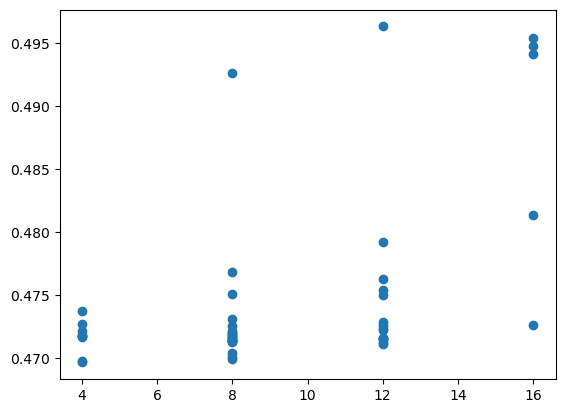

In [82]:
plt.scatter(np.asarray(allfilters),np.asarray(allloss))

In [80]:
study.trials[-1].params

{'num_conv_blocks': 3,
 'num_filters': 4,
 'num_hidden_layers': 4,
 'num_nodes_layer_0': 40,
 'num_nodes_layer_1': 40,
 'num_nodes_layer_2': 80,
 'num_nodes_layer_3': 60}